# Geospatial Machine Learning — Part 1: Exploratory Data Analysis (EDA)

This is the first of four notebooks that build a model to **predict topsoil sand content (0–50 cm) across Brazil** from environmental raster data:

1. **EDA** (this notebook): get to know the response variable and the predictors.
2. **ESDA**: measure how sand content is organized in space (Moran's I, semivariogram).
3. **Random Forest with random cross-validation**: train, validate and map the model.
4. **Random Forest with spatial cross-validation**: repeat the model with an honest, spatially independent validation.

**Data**

- *Response variable (Y):* sand content (`areia`) of soil samples from the `c3_soildata_psd_modeling_0_50cm.gpkg` point dataset, originally in g/kg and converted here to %.
- *Predictors (X):* 25 rasters at ~1 km resolution (30 arc-seconds): 19 WorldClim bioclimatic variables (`bio1`–`bio19`), elevation and terrain derivatives (`slope`, `HAND`, `TPI_11x11`, `Mean_curvature`, `NTSI`).

**Workflow**

- *Data preparation:* load the samples and the rasters, and extract the raster values at each sample location.
- *Exploratory analysis:* distribution and extreme values of sand content, missing values, predictor summaries, and correlations between sand content and the predictors.

No model is fitted here. The goal is to check data quality and form expectations before modeling.

In [1]:
# Import libraries for vector data, raster data, data manipulation and plotting.

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio

import matplotlib.pyplot as plt

## 1. Load the sample data

Each point is a soil sample with its location, depth and particle-size fractions (sand, silt and clay, in g/kg of fine earth) plus coarse fragments (`esqueleto`). Samples whose coarse fragments are 1000 g/kg contain no fine earth at all; their sand value of 0 is not a real measurement and they are removed.

In [2]:
# Input data and outputs are kept in separate folders next to this notebook.
INPUT_DIR = Path("input")

# Define the path to the point dataset containing the response variable.
samples_path = INPUT_DIR / "c3_soildata_psd_modeling_0_50cm.gpkg"

# Read the point dataset as a GeoDataFrame.
samples = gpd.read_file(samples_path)

# Drop layers made only of coarse fragments (esqueleto = 1000 g/kg).
# They contain no fine earth, so sand = 0 there is not a measurement.
samples = samples[samples["esqueleto"] < 1000].reset_index(drop=True)
print("Samples after removing esqueleto = 1000:", len(samples))

# Inspect the sample data.
samples.info()
display(samples.head())
display(samples.describe(include="all"))

Samples after removing esqueleto = 1000: 14165
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 14165 entries, 0 to 14164
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   id                        14165 non-null  str     
 1   longitude                 14165 non-null  float64 
 2   latitude                  14165 non-null  float64 
 3   profundidade              14165 non-null  float64 
 4   esqueleto                 14165 non-null  int32   
 5   areia                     14165 non-null  int32   
 6   silte                     14165 non-null  int32   
 7   argila                    14165 non-null  int32   
 8   log_silte1p_argila1p      14165 non-null  float64 
 9   log_areia1p_argila1p      14165 non-null  float64 
 10  log_esqueleto1p_argila1p  14165 non-null  float64 
 11  geometry                  14165 non-null  geometry
dtypes: float64(6), geometry(1), int32(4), str(1)
me

,id,longitude,latitude,profundidade,esqueleto,areia,silte,argila,log_silte1p_argila1p,log_areia1p_argila1p,log_esqueleto1p_argila1p,geometry
0,clay-copy-ctb0004-RosĂˇrio-26,-35.134160,-8.576835,40.0,0,200,150,650,-1.461230,-1.175205,-6.478510,POINT (-35.13416 -8.57683)
1,clay-copy-ctb0019-P1,-50.231766,-29.475679,44.0,0,120,250,630,-0.921853,-1.651515,-6.447306,POINT (-50.23177 -29.47568)
2,clay-copy-ctb0033-RO1271,-64.059444,-11.770000,50.0,0,157,67,776,-2.435933,-1.592845,-6.655440,POINT (-64.05944 -11.77)
3,clay-copy-ctb0033-RO1279,-64.330278,-12.018333,45.0,0,60,200,740,-1.304696,-2.497127,-6.608001,POINT (-64.33028 -12.01833)
4,clay-copy-ctb0033-RO1303,-63.941667,-9.891667,45.0,400,260,70,670,-2.237736,-0.942691,-0.004975,POINT (-63.94167 -9.89167)


,id,longitude,latitude,profundidade,esqueleto,areia,silte,argila,log_silte1p_argila1p,log_areia1p_argila1p,log_esqueleto1p_argila1p,geometry
count,14165,14165.000000,14165.000000,14165.000000,14165.000000,14165.000000,14165.000000,14165.000000,14165.000000,14165.000000,14165.000000,14165
unique,14057,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14165
top,clay-copy-ctb0033-RO2493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-35.13416003624 -8.576834933487826)
freq,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
mean,NaN,-53.621213,-16.082803,24.697653,64.939287,484.000424,182.003318,333.996258,-0.627611,0.498344,-3.082999,NaN
std,NaN,8.079586,8.481977,14.933753,110.124817,277.086129,140.243171,215.486282,0.918257,1.954324,2.578236,NaN
min,NaN,-73.850000,-33.686969,0.500000,0.000000,0.000000,0.000000,0.000000,-6.673298,-6.792344,-6.888572,NaN
25%,NaN,-61.150000,-22.501390,10.000000,0.000000,249.000000,77.000000,150.000000,-1.252763,-0.660357,-5.564520,NaN
50%,NaN,-54.150000,-15.936090,22.500000,10.000000,483.000000,144.000000,300.000000,-0.707513,0.423050,-3.209306,NaN
75%,NaN,-47.316670,-9.900021,39.000000,118.000000,710.000000,260.000000,492.000000,0.000000,1.474801,-0.796944,NaN


## 2. Load the raster predictors

Every GeoTIFF in the `input` folder is treated as a predictor, and its file name becomes the variable name.

In [3]:
# Define the directory containing the predictor rasters.
workdir_xvars = INPUT_DIR

# List all GeoTIFF files in the predictor directory.
raster_files = sorted(workdir_xvars.glob("*.tif"))

print(f"Number of raster predictors: {len(raster_files)}")
for f in raster_files:
    print(f.name)

Number of raster predictors: 25
HAND.tif
Mean_curvature.tif
NTSI.tif
TPI_11x11.tif
bio1.tif
bio10.tif
bio11.tif
bio12.tif
bio13.tif
bio14.tif
bio15.tif
bio16.tif
bio17.tif
bio18.tif
bio19.tif
bio2.tif
bio3.tif
bio4.tif
bio5.tif
bio6.tif
bio7.tif
bio8.tif
bio9.tif
elevation.tif
slope.tif


In [4]:
# Read raster layer names from file stems.
# These names must match the predictor columns used by the model.
raster_names = [f.stem for f in raster_files]

raster_names

['HAND',
 'Mean_curvature',
 'NTSI',
 'TPI_11x11',
 'bio1',
 'bio10',
 'bio11',
 'bio12',
 'bio13',
 'bio14',
 'bio15',
 'bio16',
 'bio17',
 'bio18',
 'bio19',
 'bio2',
 'bio3',
 'bio4',
 'bio5',
 'bio6',
 'bio7',
 'bio8',
 'bio9',
 'elevation',
 'slope']

## 3. Extract raster values at sample locations

To relate sand content to the environment, we read the value of each raster at each sample point. Points and rasters must share the same coordinate reference system (CRS) first.

In [5]:
# Check the coordinate reference system of the samples and rasters.
with rasterio.open(raster_files[0]) as src:
    raster_crs = src.crs

print("Sample CRS:", samples.crs)
print("Raster CRS:", raster_crs)

# Reproject sample points if necessary.
if samples.crs != raster_crs:
    samples = samples.to_crs(raster_crs)

Sample CRS: EPSG:4326
Raster CRS: EPSG:4326


In [6]:
# Extract raster values at each sample location.
# One new column is created for each raster predictor.

coords = [(geom.x, geom.y) for geom in samples.geometry]

for raster_path, raster_name in zip(raster_files, raster_names):
    with rasterio.open(raster_path) as src:
        values = [v[0] for v in src.sample(coords)]

        # Convert raster nodata values to NaN.
        if src.nodata is not None:
            values = [
                np.nan if v == src.nodata else v
                for v in values
            ]

        samples[raster_name] = values

display(samples.head())

,id,longitude,latitude,profundidade,esqueleto,areia,silte,argila,log_silte1p_argila1p,log_areia1p_argila1p,...,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,elevation,slope
0,clay-copy-ctb0004-RosĂˇrio-26,-35.134160,-8.576835,40.0,0,200,150,650,-1.461230,-1.175205,...,6.566667,69.122803,105.115379,29.000000,19.500000,9.500000,23.566666,24.783333,36.0,0.960910
1,clay-copy-ctb0019-P1,-50.231766,-29.475679,44.0,0,120,250,630,-0.921853,-1.651515,...,8.783334,51.364521,305.108032,23.600000,6.500000,17.100000,18.783333,15.983334,916.0,0.110330
2,clay-copy-ctb0033-RO1271,-64.059444,-11.770000,50.0,0,157,67,776,-2.435933,-1.592845,...,11.125000,73.190796,67.367989,33.099998,17.900000,15.199999,26.150000,25.166666,158.0,0.515958
3,clay-copy-ctb0033-RO1279,-64.330278,-12.018333,45.0,0,60,200,740,-1.304696,-2.497127,...,10.850000,73.809525,69.870026,33.000000,18.299999,14.700001,26.366667,25.333334,148.0,0.137899
4,clay-copy-ctb0033-RO1303,-63.941667,-9.891667,45.0,400,260,70,670,-2.237736,-0.942691,...,11.691667,72.619049,53.262882,33.500000,17.400000,16.100000,25.783333,25.100000,163.0,0.343252


## 4. Prepare the modeling dataset

We keep only the response (`areia`) and the raster predictors. Coordinates, depth, coarse fragments and the other particle-size fractions are dropped: silt and clay are not valid predictors because sand + silt + clay = 1000 g/kg, so they would reveal the answer. Missing values are kept for now so we can inspect them.

In [7]:
# Remove geometry and variables that will not be used as predictors.
columns_to_remove = [
    "id",
    "longitude",
    "latitude",
    "profundidade",
    "esqueleto",
    "silte",
    "argila",
    "log_silte1p_argila1p",
    "log_areia1p_argila1p",
    "log_esqueleto1p_argila1p",
]

samples_df = samples.drop(columns="geometry").copy()

samples_df = samples_df.drop(
    columns=[c for c in columns_to_remove if c in samples_df.columns]
)

# Keep missing values during exploratory data analysis.
print("Number of samples:", len(samples_df))

display(samples_df.head())
display(samples_df.describe())

Number of samples: 14165


,areia,HAND,Mean_curvature,NTSI,TPI_11x11,bio1,bio10,bio11,bio12,bio13,...,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,elevation,slope
0,200,29.005001,-4.573328e-06,0.000083,-6.528925,24.391666,25.516666,22.983334,2119.0,328.0,...,6.566667,69.122803,105.115379,29.000000,19.500000,9.500000,23.566666,24.783333,36.0,0.960910
1,120,773.000000,9.522858e-06,-0.001479,173.289261,14.950000,18.783333,11.350000,1997.0,191.0,...,8.783334,51.364521,305.108032,23.600000,6.500000,17.100000,18.783333,15.983334,916.0,0.110330
2,157,0.000000,-8.854991e-06,0.005365,-16.669422,25.970833,26.666666,24.983334,1583.0,253.0,...,11.125000,73.190796,67.367989,33.099998,17.900000,15.199999,26.150000,25.166666,158.0,0.515958
3,60,0.000000,-2.143425e-07,0.003746,-11.256198,26.200001,26.950001,25.200001,1555.0,251.0,...,10.850000,73.809525,69.870026,33.000000,18.299999,14.700001,26.366667,25.333334,148.0,0.137899
4,260,38.011002,6.404418e-07,-0.003907,-0.975207,25.712500,26.283335,24.966667,2036.0,320.0,...,11.691667,72.619049,53.262882,33.500000,17.400000,16.100000,25.783333,25.100000,163.0,0.343252


,areia,HAND,Mean_curvature,NTSI,TPI_11x11,bio1,bio10,bio11,bio12,bio13,...,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,elevation,slope
count,14165.000000,13678.000000,1.410600e+04,14094.000000,14106.000000,14106.000000,14106.000000,14106.000000,14106.000000,14106.000000,...,14106.000000,14106.000000,14106.000000,14106.000000,14106.000000,14106.000000,14106.000000,14106.000000,14106.000000,13906.000000
mean,484.000424,108.752304,3.532008e-07,0.002758,1.693991,22.975729,24.839281,20.760132,1639.562134,252.926834,...,11.235254,66.139038,170.955002,31.215675,13.924968,17.290707,23.361038,21.763035,351.159152,1.198571
std,277.086129,152.224411,2.488328e-05,0.012252,44.766823,3.130940,2.088393,4.406459,395.589783,70.078323,...,1.456266,9.173116,118.851433,2.446540,4.339822,2.955766,3.461945,4.014246,312.469118,1.605366
min,0.000000,0.000000,-1.851026e-04,-0.064239,-389.107452,9.283334,11.466667,6.766666,379.000000,64.000000,...,5.966666,38.904236,23.880211,16.600000,-1.300000,8.900000,10.933333,6.766666,0.000000,0.000000
25%,249.000000,20.000000,-6.956573e-06,-0.001108,-12.801653,20.054167,23.700001,16.799999,1448.000000,188.000000,...,10.400000,60.738937,64.467529,30.100000,10.000000,15.700001,22.299999,18.920834,126.000000,0.312560
50%,483.000000,50.000000,0.000000e+00,0.001203,-0.520661,23.979166,25.216667,22.350000,1629.000000,261.000000,...,11.458334,68.333336,156.496918,31.700001,14.600000,18.099998,24.733334,22.783333,231.000000,0.680307
75%,710.000000,136.000000,8.020527e-06,0.003150,13.849174,25.379168,26.299999,24.483334,1843.000000,311.000000,...,12.416666,71.452698,236.427795,33.099998,17.100000,19.100000,25.683334,24.816666,518.000000,1.368558
max,1000.000000,2046.005981,2.857003e-04,0.157383,591.388428,28.066666,29.483334,27.333334,3624.000000,585.000000,...,15.208334,90.591385,461.137207,36.400002,22.900000,24.200001,28.166666,28.533333,2666.000000,17.722532


In [8]:
# Convert sand content to percent.
samples_df["areia"] = samples_df["areia"] / 10

## 5. Exploratory data analysis

Before training any model, we look at:

- how sand content is distributed (skewness, range, extreme values);
- how many values are missing in each variable;
- which predictors are linearly related to sand content and to each other.

### 5.1 Distribution of the response variable

The histogram shows whether sand content is symmetric, skewed or multimodal, which affects the choice of model and evaluation metrics.

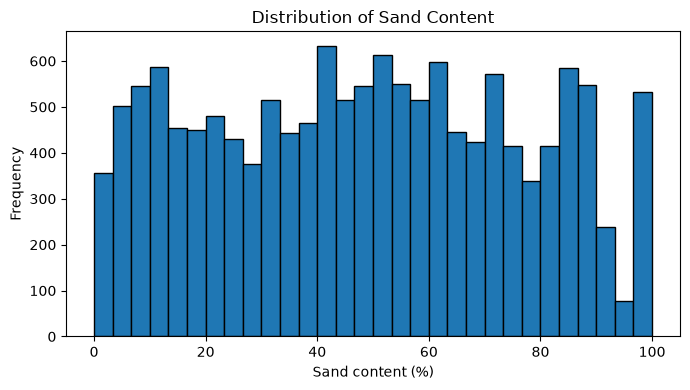

In [9]:
# Check the distribution of sand content.
plt.figure(figsize=(7, 4))

plt.hist(
    samples_df["areia"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.xlabel("Sand content (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Sand Content")
plt.tight_layout()
plt.show()

### 5.2 Range and extreme values

Sand content is bounded between 0 % and 100 %. The summary statistics and the boxplot show how values spread within this range and whether there are outliers.

In [10]:
# Summarize the range and descriptive statistics of sand content.
sand_summary = samples_df["areia"].describe()

display(sand_summary.to_frame(name="Sand content (%)"))

print(f"Minimum sand content: {samples_df['areia'].min():.2f}%")
print(f"Maximum sand content: {samples_df['areia'].max():.2f}%")

,Sand content (%)
count,14165.000000
mean,48.400042
std,27.708613
min,0.000000
25%,24.900000
50%,48.300000
75%,71.000000
max,100.000000


Minimum sand content: 0.00%
Maximum sand content: 100.00%


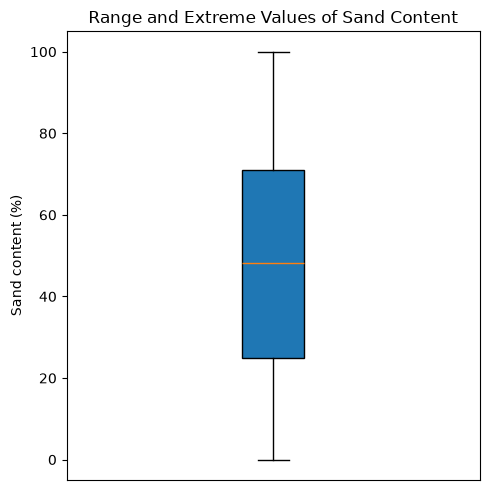

In [11]:
# Use a boxplot to inspect the distribution and potential extreme values.
plt.figure(figsize=(5, 5))

plt.boxplot(
    samples_df["areia"].dropna(),
    orientation="vertical",
    patch_artist=True
)

plt.ylabel("Sand content (%)")
plt.title("Range and Extreme Values of Sand Content")
plt.xticks([])
plt.tight_layout()
plt.show()

### 5.3 Missing values

Raster values can be missing where a point falls on a no-data pixel (e.g. water bodies, coastline or the edge of a raster). Variables with many missing values reduce the number of complete samples available for modeling.

In [12]:
# Check for missing values in the response and predictors.
missing_values = pd.DataFrame({
    "variable": samples_df.columns,
    "n_missing": samples_df.isna().sum().values,
    "percent_missing": (
        samples_df.isna().mean().values * 100
    )
})

missing_values = missing_values.sort_values(
    "n_missing",
    ascending=False
).reset_index(drop=True)

display(missing_values)

,variable,n_missing,percent_missing
0,HAND,487,3.438052
1,slope,259,1.828450
2,NTSI,71,0.501235
3,bio10,59,0.416520
4,TPI_11x11,59,0.416520
5,Mean_curvature,59,0.416520
6,bio12,59,0.416520
7,bio11,59,0.416520
8,bio13,59,0.416520
9,bio1,59,0.416520


### 5.4 What information is available to explain Y?

List of the candidate predictors with their data type, availability and summary statistics.

In [13]:
# Identify the predictor variables available to explain sand content.
predictor_names_eda = [
    col for col in samples_df.columns
    if col != "areia"
]

print("Response variable:")
print("areia")

print(f"\nNumber of predictors: {len(predictor_names_eda)}")

print("\nPredictor variables available to explain sand content:")
print(predictor_names_eda)

# Summarize predictor type and data availability.
predictor_info = pd.DataFrame({
    "variable": predictor_names_eda,
    "dtype": samples_df[predictor_names_eda].dtypes.astype(str).values,
    "n_available": samples_df[predictor_names_eda].notna().sum().values,
    "n_missing": samples_df[predictor_names_eda].isna().sum().values
})

display(predictor_info)

# Summarize the predictor variables.
display(samples_df[predictor_names_eda].describe().T)

Response variable:
areia

Number of predictors: 25

Predictor variables available to explain sand content:
['HAND', 'Mean_curvature', 'NTSI', 'TPI_11x11', 'bio1', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'elevation', 'slope']


,variable,dtype,n_available,n_missing
0,HAND,float32,13678,487
1,Mean_curvature,float32,14106,59
2,NTSI,float32,14094,71
3,TPI_11x11,float32,14106,59
4,bio1,float32,14106,59
5,bio10,float32,14106,59
6,bio11,float32,14106,59
7,bio12,float32,14106,59
8,bio13,float32,14106,59
9,bio14,float32,14106,59


,count,mean,std,min,25%,50%,75%,max
HAND,13678.0,1.087523e+02,152.224411,0.000000,20.000000,50.000000,136.000000,2046.005981
Mean_curvature,14106.0,3.532008e-07,0.000025,-0.000185,-0.000007,0.000000,0.000008,0.000286
NTSI,14094.0,2.757896e-03,0.012252,-0.064239,-0.001108,0.001203,0.003150,0.157383
TPI_11x11,14106.0,1.693991e+00,44.766823,-389.107452,-12.801653,-0.520661,13.849174,591.388428
bio1,14106.0,2.297573e+01,3.130940,9.283334,20.054167,23.979166,25.379168,28.066666
bio10,14106.0,2.483928e+01,2.088393,11.466667,23.700001,25.216667,26.299999,29.483334
bio11,14106.0,2.076013e+01,4.406459,6.766666,16.799999,22.350000,24.483334,27.333334
bio12,14106.0,1.639562e+03,395.589783,379.000000,1448.000000,1629.000000,1843.000000,3624.000000
bio13,14106.0,2.529268e+02,70.078323,64.000000,188.000000,261.000000,311.000000,585.000000
bio14,14106.0,4.095683e+01,44.605137,0.000000,11.000000,18.000000,65.000000,238.000000


### 5.5 Correlation between Y and the predictors

Pearson correlation measures only **linear** association. A weak correlation does not mean a predictor is useless: Random Forest can also capture non-linear relationships and interactions.

In [14]:
# Keep only numeric variables for correlation analysis.
numeric_data = samples_df.select_dtypes(
    include=np.number
)

# Compute the Pearson correlation matrix using available value pairs.
cor_matrix = numeric_data.corr(
    method="pearson",
    min_periods=2
)

# Rank predictors by the absolute correlation with sand content.
sand_correlations = (
    cor_matrix["areia"]
    .drop(labels="areia")
    .rename("correlation_with_sand")
    .to_frame()
)

sand_correlations["abs_correlation"] = (
    sand_correlations["correlation_with_sand"].abs()
)

sand_correlations = sand_correlations.sort_values(
    "abs_correlation",
    ascending=False
).drop(columns="abs_correlation")

display(sand_correlations)

,correlation_with_sand
NTSI,0.331044
bio10,0.263323
bio5,0.258039
bio9,0.257559
bio1,0.241013
bio17,-0.225232
bio14,-0.213033
bio11,0.211819
elevation,-0.211709
bio6,0.202286


### 5.6 Correlation matrix

The full matrix also shows correlations **among predictors**. Many bioclimatic variables are strongly correlated with each other (e.g. the temperature variables `bio1`, `bio5`, `bio6`, `bio10`, `bio11`), so they carry overlapping information. This redundancy should be kept in mind when interpreting variable importance later.

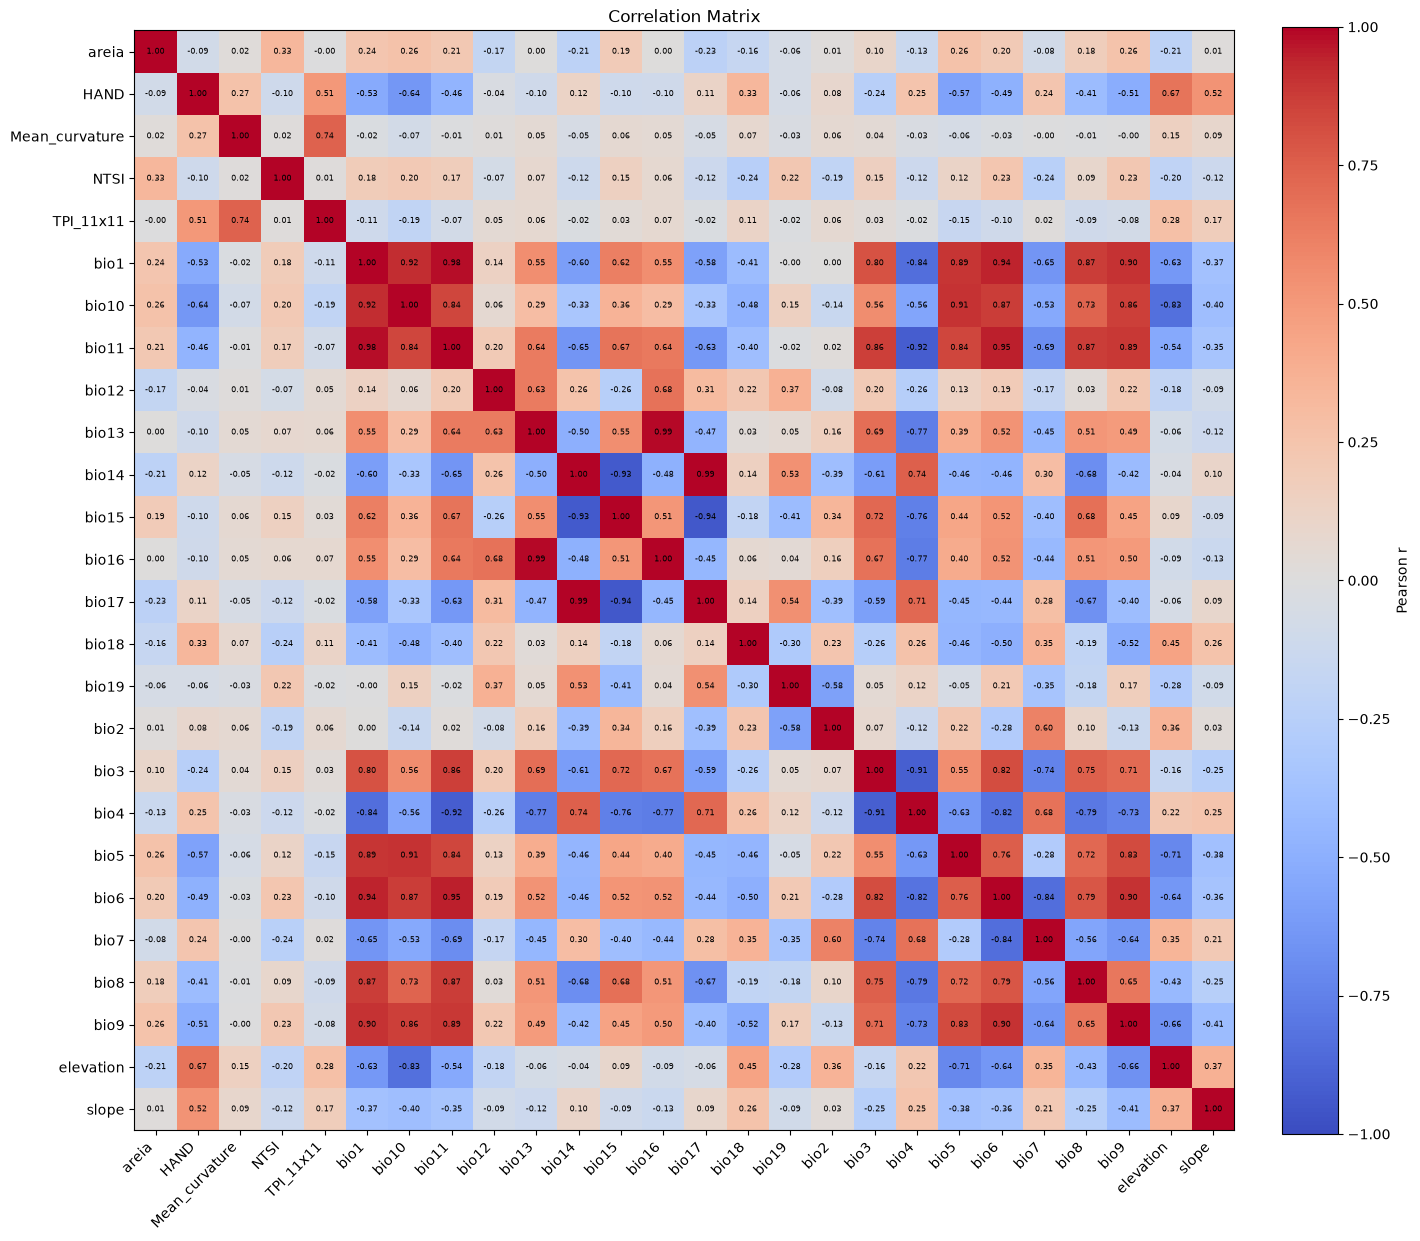

In [15]:
# Plot the Pearson correlation matrix with correlation coefficients.
variables = cor_matrix.columns
n_vars = len(variables)

fig_size = max(8, 0.55 * n_vars)
fig, ax = plt.subplots(
    figsize=(fig_size, fig_size)
)

im = ax.imshow(
    cor_matrix,
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

ax.set_xticks(range(n_vars))
ax.set_yticks(range(n_vars))

ax.set_xticklabels(
    variables,
    rotation=45,
    ha="right"
)
ax.set_yticklabels(variables)

# Add correlation coefficients to each matrix cell.
font_size = 8 if n_vars <= 15 else 6

for i in range(n_vars):
    for j in range(n_vars):
        value = cor_matrix.iloc[i, j]

        if np.isfinite(value):
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=font_size
            )

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.04
)
cbar.set_label("Pearson r")

ax.set_title("Correlation Matrix")
fig.tight_layout()
plt.show()

## 6. Summary

- After removing the 664 samples without fine earth, **14,165 samples** remain. Sand content covers the full 0–100 % range, with a mean and median close to 48 %.
- Missing values are few: at most 3.4 % (`HAND`), and about 0.4 % for most rasters (points falling on no-data pixels). Removing incomplete samples will leave about 13,600 samples for modeling.
- **Linear correlations with sand are weak** (|r| ≤ 0.33). The strongest are `NTSI` (+0.33), the temperature variables `bio10`, `bio5`, `bio9`, `bio1` (+0.24 to +0.26) and dry-season precipitation `bio17`/`bio14` (≈ −0.22). No single predictor explains sand content, which motivates a multivariate, non-linear model such as Random Forest (Parts 3 and 4).
- Many predictors are strongly correlated with each other, so variable importance must be interpreted for groups of related variables rather than for individual rasters.